# Filling Missing Budget Data

To improve our analysis, we filled in missing budget values using a secondary dataset from The Numbers.

In [1]:
import pandas as pd

# Load data
df = pd.read_csv("data/Highest Holywood Grossing Movies.csv")
budget_df = pd.read_csv("data/TheNumbers_budget_data.csv", encoding='latin1')

# Clean columns (trailing spaces)
budget_df.columns = budget_df.columns.str.strip()

# Clean titles for merge
df['Title'] = df['Title'].astype(str).str.strip().str.lower()
budget_df['Movie'] = budget_df['Movie'].astype(str).str.strip().str.lower()

# Clean and convert budget values
budget_df['Production Budget'] = (
    budget_df['Production Budget']
    .replace(r'[\$,]', '', regex=True)
    .str.replace('\xa0', '')
    .astype(float)
)
df['Budget (in $)'] = pd.to_numeric(df['Budget (in $)'], errors='coerce')

# Build map and fill missing budgets
budget_map = budget_df.set_index('Movie')['Production Budget'].to_dict()
def fill_budget(row):
    if pd.isna(row['Budget (in $)']):
        return budget_map.get(row['Title'], row['Budget (in $)'])
    return row['Budget (in $)']

df['Budget (in $)'] = df.apply(fill_budget, axis=1)

# Load and Enrich Dataset with OMDb API
We load a dataset of high-grossing Hollywood movies and enrich it with additional metadata (director and IMDb rating) using the OMDb API.

In [2]:
import requests
import time

# OMDb API key
api_key = "d43dbb7e"

# Make sure the necessary columns exist
df["Director"] = ""
df["IMDb_Rating"] = ""

# Loop through rows and fetch OMDb data
for i, row in df.iterrows():
    title = str(row["Title"]).strip()
    year = str(row["Year"]).strip()

    # Build API URL
    url = f"http://www.omdbapi.com/?t={title}&y={year}&apikey={api_key}"

    try:
        res = requests.get(url)
        data = res.json()

        if data.get("Response") == "True":
            df.at[i, "Director"] = data.get("Director", "")
            df.at[i, "IMDb_Rating"] = data.get("imdbRating", "")
        else:
            print(f"Not found: {title} ({year})")

    except Exception as e:
        print(f"Error fetching {title}: {e}")

Not found: demon slayer the movie: mugen train (2020)
Not found: mrs. doubtfire (1993)
Not found: hello mr. billionaire (2018)
Not found: mr. peabody & sherman (2014)
Not found: legend of deification (2020)
Not found: mr. bean's holiday (2007)
Not found: goodbye mr. loser (2015)
Not found: interview with the vampire: the vampire chronicles (1994)
Not found: mr. popper's penguins (2011)


In [3]:
# convert the dataset to csv
df.to_csv('final_dataset.csv', index = False)

In [4]:
#Display missing values 
print(df.isnull().sum())

Unnamed: 0                      0
Title                           0
Movie Info                      0
Year                            0
Distributor                     1
Budget (in $)                 128
Domestic Opening (in $)         0
Domestic Sales (in $)           0
International Sales (in $)      0
World Wide Sales (in $)         0
Release Date                    0
Genre                           0
Running Time                    0
License                        57
Director                        0
IMDb_Rating                     0
dtype: int64


# Data Cleaning and Feature Engineering

We perform essential transformations to prepare the dataset for analysis:

- Drop rows with missing budget data (required for ROI calculation)
- Convert budget and world-wide sales to numeric formats
- Calculate Return on Investment (ROI) as a %
- Convert runtime from "X hr Y min" strings to total minutes
- Parse release dates and extract numeric month for seasonal analysis


In [5]:
import numpy as np
import re
import ast

# Drop rows where budget is missing (cannot compute ROI without it)
df = df.dropna(subset=['Budget (in $)'])

# Convert Budget to integer for math operations
df['Budget (in $)'] = df['Budget (in $)'].astype(int)

# Ensure World Wide Sales is numeric (some entries may be malformed strings)
df['World Wide Sales (in $)'] = pd.to_numeric(df['World Wide Sales (in $)'], errors='coerce')

# Compute Return on Investment (ROI) in percentage terms
df['ROI'] = ((df['World Wide Sales (in $)'] - df['Budget (in $)']) / df['Budget (in $)']) * 100 

# Function to convert "X hr Y min" strings into total minutes
def to_minutes(runtime_str):
    if pd.isna(runtime_str):
        return None
    match = re.match(r'(?:(\d+)\s*hr)?\s*(\d+)\s*min', runtime_str)
    if match:
        hours = int(match.group(1)) if match.group(1) else 0
        mins = int(match.group(2)) if match.group(2) else 0
        return hours * 60 + mins
    return None

# Apply runtime conversion to new column
df['Running Time (minutes)'] = df['Running Time'].apply(to_minutes)

# Convert release date column to datetime format
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')

# Extract numeric month
df['Release_Month'] = df['Release Date'].dt.month

C:\Users\Admin\AppData\Local\Temp\ipykernel_17364\509969539.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')


# Exploring Genre Patterns

We break down the dataset by genre to understand two key aspects:
- How frequently each genre appears in the dataset
- How profitable each genre is on average, using Return on Investment (ROI)

The dual-axis chart below shows the number of movies in each genre (bar chart)
and the average ROI capped at 1000% (line chart) to reduce the impact of extreme outliers.

To complement this, the scatterplot below compares each film’s ROI to its worldwide revenue, revealing a weak but positive correlation

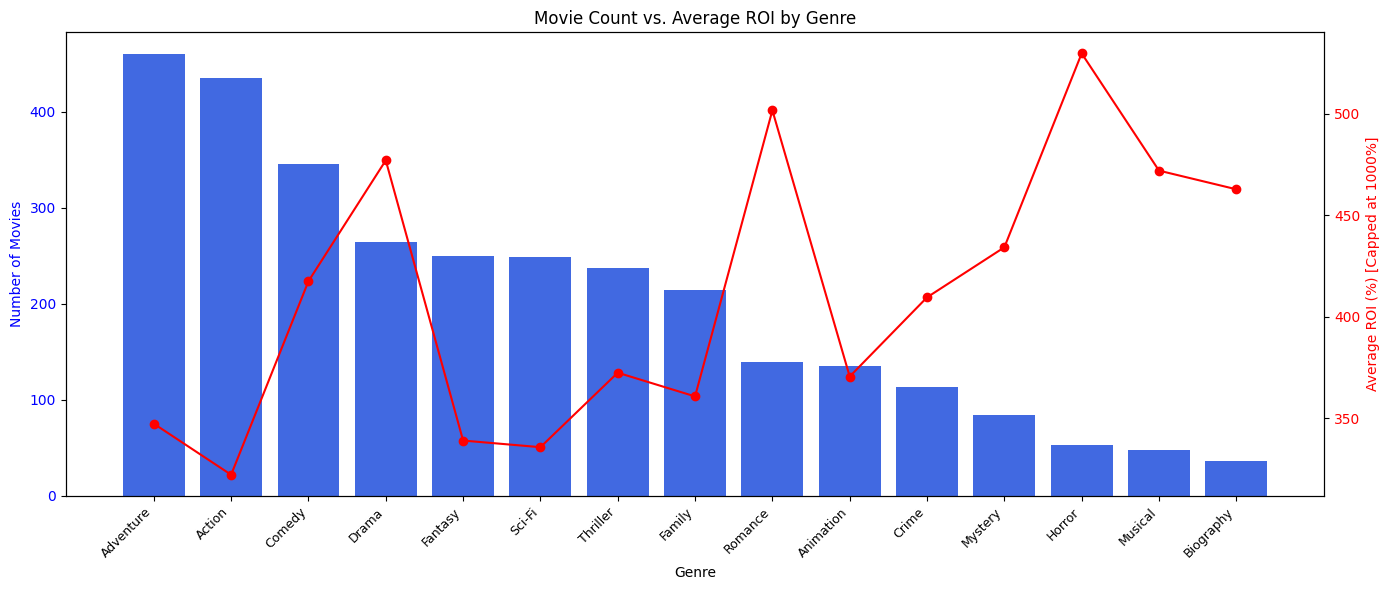

In [6]:
import matplotlib.pyplot as plt 

# Ensure correct types for calculations
df['World Wide Sales (in $)'] = pd.to_numeric(df['World Wide Sales (in $)'], errors='coerce')

# Keep original Genre column for regression 
df['Genre_Original'] = df['Genre']

# Attempt to parse Genre as a list
def parse_genre(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []

df['Genre'] = df['Genre'].apply(parse_genre)

df_exploded = df.explode('Genre').copy()

# Ensure ROI is numeric
df_exploded['ROI'] = pd.to_numeric(df_exploded['ROI'], errors='coerce')

# Cap ROI at 1000% (10x) to reduce outlier influence
df_exploded['ROI_Capped'] = df_exploded['ROI'].clip(upper=1000)

# Group by Genre to calculate movie count and average ROI
genre_summary_capped = df_exploded.groupby('Genre').agg(
    Movie_Count=('Genre', 'count'),
    Avg_ROI=('ROI_Capped', 'mean')
).sort_values('Movie_Count', ascending=False).head(15)

# Re-plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar plot: Movie count
ax1.bar(genre_summary_capped.index, genre_summary_capped['Movie_Count'], color='royalblue')
ax1.set_xlabel('Genre')
ax1.set_ylabel('Number of Movies', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45, ha='right', fontsize=9)

# Line plot: Average ROI
ax2 = ax1.twinx()
ax2.plot(genre_summary_capped.index, genre_summary_capped['Avg_ROI'], color='red', marker='o')
ax2.set_ylabel('Average ROI (%) [Capped at 1000%]', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Movie Count vs. Average ROI by Genre')
plt.tight_layout()
plt.show()

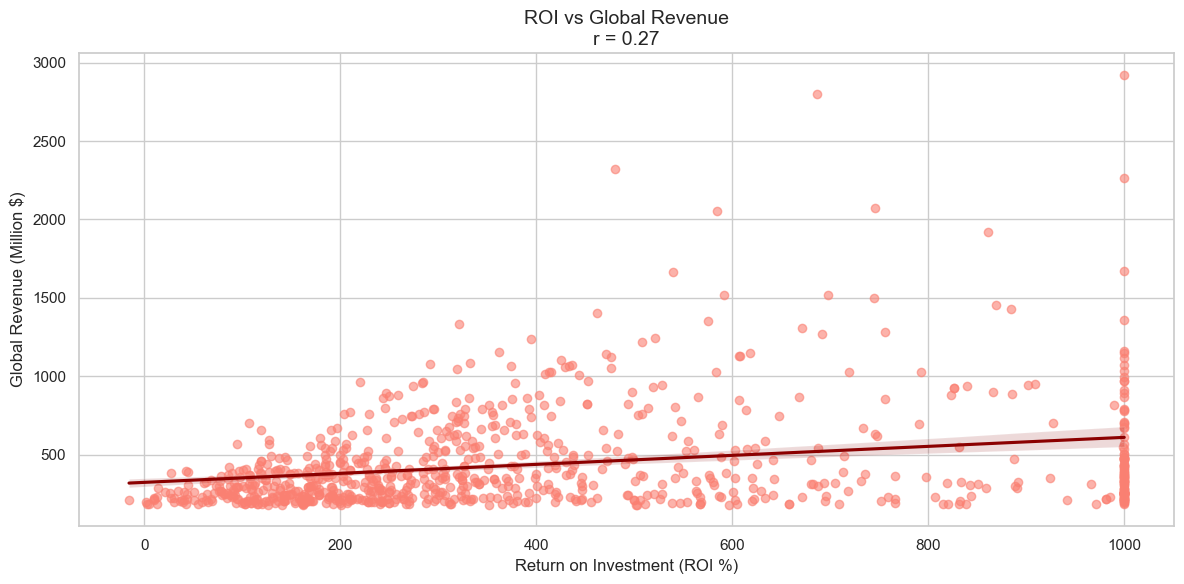

In [7]:
from scipy.stats import pearsonr
import seaborn as sns

# Clean column names for easier use
df = df.rename(columns={
    'Budget (in $)': 'Budget',
    'World Wide Sales (in $)': 'Revenue',
})

# Drop rows with missing or zero budget/revenue
df_clean = df.dropna(subset=['ROI', 'Revenue'])

# Convert revenue to millions 
df_clean['Revenue_Millions'] = df_clean['Revenue'] / 1e6

# Cap ROI at 1000% for better visual clarity
df_clean['ROI_Capped'] = df_clean['ROI'].clip(upper=1000)

# Pearson correlation (on uncapped ROI)
corr, _ = pearsonr(df_clean['ROI_Capped'], df_clean['Revenue_Millions'])

# Plot
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

sns.regplot(
    data=df_clean,
    x='ROI_Capped', y='Revenue_Millions',
    scatter_kws={'alpha': 0.6, 'color': 'salmon'},
    line_kws={'color': 'darkred'}
)

plt.title(f'ROI vs Global Revenue\nr = {corr:.2f}', fontsize=14)
plt.xlabel('Return on Investment (ROI %)')
plt.ylabel('Global Revenue (Million $)')
plt.tight_layout()
plt.show() 

# Ratings vs. ROI: Correlation Analysis

This section explores the relationship between a movie’s IMDb rating and its Return on Investment (ROI) capped at 1000%.

Below, we also highlight a few notable **low-rated movies (IMDb < 6.0)** that still were exceptionally profitable 

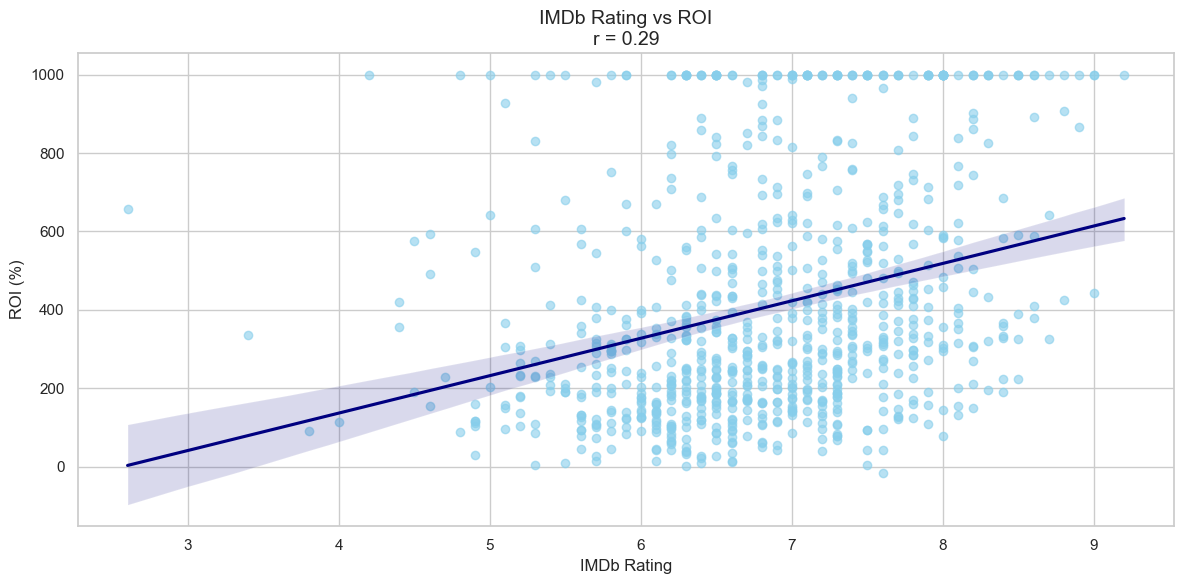

In [8]:
from scipy.stats import pearsonr
import seaborn as sns 

# Convert columns to numeric
df['IMDb_Rating'] = pd.to_numeric(df['IMDb_Rating'], errors='coerce')

# Create capped ROI column (1000% max)
df['ROI_Capped'] = df['ROI'].clip(upper=1000)

# Filter valid rows
rating_df = df[['IMDb_Rating', 'ROI', 'ROI_Capped', 'Title']].dropna()

# Pearson correlation (IMDb vs uncapped ROI for accuracy)
imdb_corr, _ = pearsonr(rating_df['IMDb_Rating'], rating_df['ROI_Capped'])

# Plot
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

sns.regplot(
    data=rating_df,
    x='IMDb_Rating', y='ROI_Capped',
    scatter_kws={'alpha': 0.6, 'color': 'skyblue'},
    line_kws={'color': 'navy'}
)

plt.title(f'IMDb Rating vs ROI\nr = {imdb_corr:.2f}', fontsize=14)
plt.xlabel('IMDb Rating')
plt.ylabel('ROI (%)')
plt.tight_layout()
plt.show()

In [9]:
# Filter for movies with low IMDb rating (< 6.0)
ratings_outliers = df[df['IMDb_Rating'].astype(float) < 6.0]

# Sort by ROI descending
ratings_outliers = ratings_outliers.sort_values(by='ROI', ascending=False)

# Show top 3 outliers
ratings_outliers[['Title', 'IMDb_Rating', 'ROI']].head(3)

,Title,IMDb_Rating,ROI
851,paranormal activity 3,5.8,4040.796880
642,annabelle,5.5,3862.918785
81,wolf warrior 2,5.9,2791.446641


# Runtime and Profitability

We analyze how movie length relates to financial success. The chart below shows the average ROI across three runtime categories. 

Despite longer films typically earning more, several short movies (under 90 minutes) also delivered outstanding returns. The table highlights the top-performing short films by ROI.


C:\Users\Admin\AppData\Local\Temp\ipykernel_17364\772213223.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  runtime_df['Runtime Category'] = runtime_df['Running Time (minutes)'].apply(categorize_runtime)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17364\772213223.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


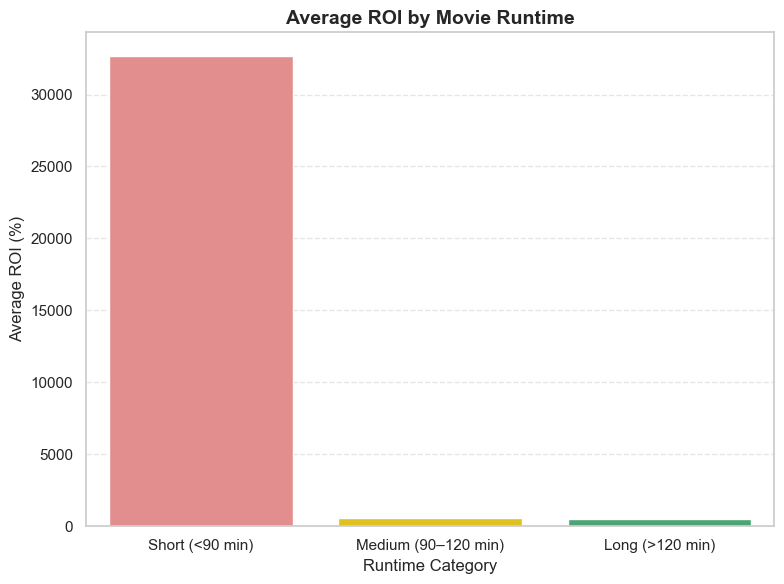

In [10]:
# Categorize runtime into bins
def categorize_runtime(minutes):
    if minutes < 90:
        return 'Short (<90 min)'
    elif minutes <= 120:
        return 'Medium (90–120 min)'
    else:
        return 'Long (>120 min)'

# Filter valid rows
runtime_df = df.dropna(subset=['Running Time (minutes)', 'ROI'])

# Apply runtime category
runtime_df['Runtime Category'] = runtime_df['Running Time (minutes)'].apply(categorize_runtime)

# Compute average ROI by category
avg_roi = (
    runtime_df.groupby('Runtime Category')['ROI']
    .mean()
    .reindex(['Short (<90 min)', 'Medium (90–120 min)', 'Long (>120 min)'])
)

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x=avg_roi.index,
    y=avg_roi.values,
    palette=['lightcoral', 'gold', 'mediumseagreen']
)
plt.title('Average ROI by Movie Runtime', fontsize=14, fontweight='bold')
plt.xlabel('Runtime Category')
plt.ylabel('Average ROI (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
# Calculate the 75th percentile ROI value (top 25%)
roi_threshold = df['ROI'].quantile(0.75)

# Filter for "short" movies under 90 minutes
df['Running Time (minutes)'] = pd.to_numeric(df['Running Time (minutes)'], errors='coerce')
short_movies = df[df['Running Time (minutes)'] < 90]

# Select only the hits
short_hits = short_movies[short_movies['ROI'] >= roi_threshold].copy()

# Sort and take top 3
top_hits = short_hits[['Title', 'Running Time (minutes)', 'ROI']].sort_values('ROI', ascending=False).head(3)

# Format ROI nicely for display
top_hits['ROI'] = top_hits['ROI'].apply(lambda x: f"{x:.2f}")

# Show final result
print(top_hits)

                       Title  Running Time (minutes)         ROI
926      paranormal activity                    86.0  1288938.67
671  the blair witch project                    81.0   414298.50
851    paranormal activity 3                    83.0     4040.80


# Top-Performing Directors

We highlight the top 10 directors based on their average Return on Investment (ROI), considering only those with at least 3 films in the dataset.

The chart below shows each director’s average ROI, annotated with the title of their highest-ROI film.


C:\Users\Admin\AppData\Local\Temp\ipykernel_17364\1692379323.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


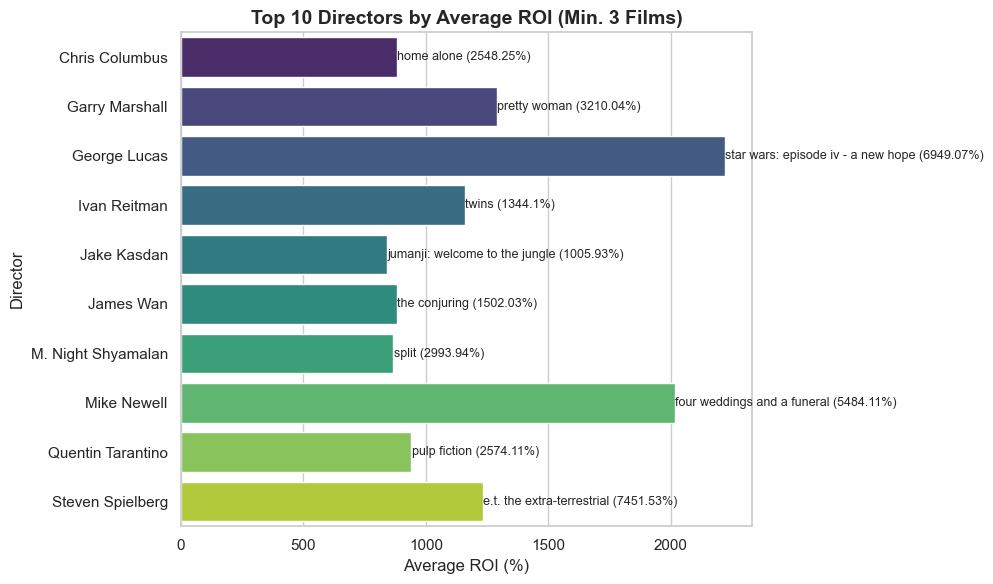

In [12]:
# Filter for rows with valid Director and ROI
df_valid = df[df['Director'].notna() & df['ROI'].notna()]

# Compute average ROI and count of films per director (min 3 films)
director_stats = (
    df_valid.groupby('Director')
    .agg(film_count=('Title', 'count'), avg_roi=('ROI', 'mean'))
    .query('film_count >= 3')
    .sort_values('avg_roi', ascending=False)
    .head(10)
    .reset_index()
)

# Filter main df to only these directors
top_directors = director_stats['Director'].tolist()
top_movies_df = df[df['Director'].isin(top_directors)]

# Get each director's top ROI movie
best_movies = (
    top_movies_df.sort_values(by='ROI', ascending=False)
    .groupby('Director')
    .first()
    .reset_index()
)[['Director', 'Title', 'ROI']]

# Merge with stats
summary_table = best_movies.merge(director_stats, on='Director')

# Round for display
summary_table['ROI'] = (summary_table['ROI']).round(2)
summary_table['avg_roi'] = (summary_table['avg_roi']).round(2)


# Plot average ROI
plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_table,
    x='avg_roi',
    y='Director',
    palette='viridis'
)

# Annotate with top movie and ROI
for i, row in summary_table.iterrows():
    plt.text(row['avg_roi'] + 1, i, f"{row['Title']} ({row['ROI']}%)", va='center', fontsize=9)

plt.title('Top 10 Directors by Average ROI (Min. 3 Films)', fontsize=14, fontweight='bold')
plt.xlabel('Average ROI (%)')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

# Distributor Performance

We evaluate studio performance by calculating the average ROI for each distributor (with at least 5 movies in the dataset). The chart highlights the top 10 based on profitability.

C:\Users\Admin\AppData\Local\Temp\ipykernel_17364\4102695467.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


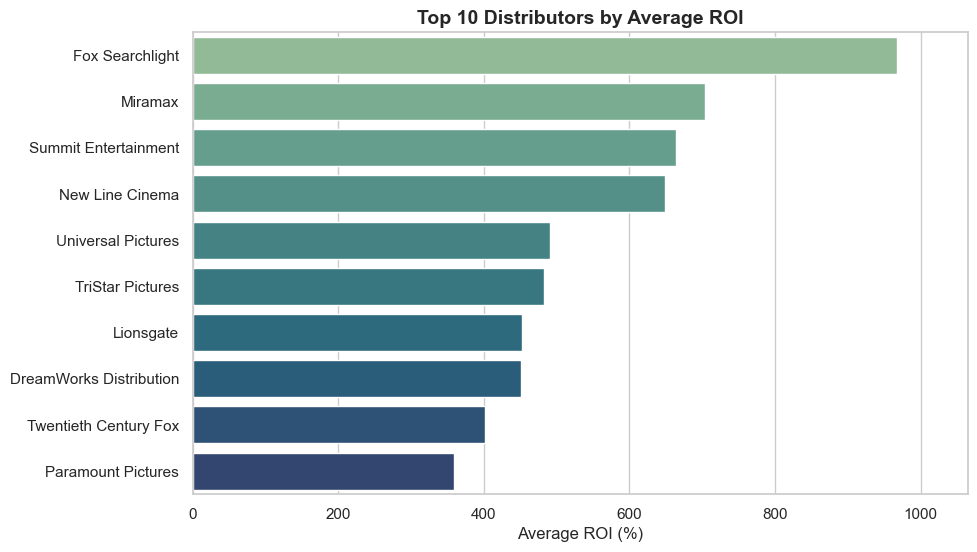

In [13]:
# Group by Distributor
distributor_stats = (
    df.groupby('Distributor')
    .agg(
        Total_Movies=('Title', 'count'),
        Avg_ROI=('ROI_Capped', 'mean')
    )
)

# Filter to distributors with at least 5 movies
distributor_stats = distributor_stats[distributor_stats['Total_Movies'] >= 5]

# Prepare top 10 distributors by Average ROI
top_distributors = (
    distributor_stats.sort_values(by='Avg_ROI', ascending=False)
    .head(10)
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_distributors,
    x='Avg_ROI',
    y='Distributor',
    palette='crest'
)

plt.title('Top 10 Distributors by Average ROI', fontsize=14, fontweight='bold')
plt.xlabel('Average ROI (%)')
plt.ylabel('')
plt.xlim(0, top_distributors['Avg_ROI'].max() * 1.1)
plt.show()

# Predicting Global Revenue with Linear Regression

We use both a scikit-learn pipeline and a statsmodels OLS model to predict log-transformed global box office revenue based on:

- IMDb rating
- Runtime
- Release month
- Main genre (as dummy variables)
- Log-transformed budget

The model allows us to evaluate both predictive performance (via R² and MSE) and statistical significance of individual features.

In [14]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from patsy import dmatrices
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Select and clean relevant columns
cols_needed = ['Revenue', 'IMDb_Rating', 'Running Time (minutes)',
               'Release_Month', 'Genre_Original', 'Budget']
df_clean = df[cols_needed].dropna()

# Simplify Genre to first listed genre
df_clean['Main_Genre'] = df_clean['Genre_Original'].apply(lambda x: eval(x)[0] if isinstance(x, str) else 'Unknown')

# Log-transform Budget to handle skewness
df_clean['Log_Budget'] = np.log1p(df_clean['Budget'])

# Log-transform World Wide Sales to reduce effect of outliers
df_clean['Log_Revenue'] = np.log1p(df_clean['Revenue'])

# Define features and target
X = df_clean[['IMDb_Rating', 'Running Time (minutes)', 'Release_Month', 'Main_Genre', 'Log_Budget']]
y = df_clean['Log_Revenue']

# One-hot encode Main_Genre, keep numerical columns as-is
preprocessor = ColumnTransformer(
    transformers=[
        ('genre', OneHotEncoder(drop='first'), ['Main_Genre'])
    ],
    remainder='passthrough'
)

# Pipeline: preprocessing + linear regression
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mse, r2)

# Define formula for OLS (convert categorical genre to dummy with C())
formula = 'Log_Revenue ~ IMDb_Rating + Q("Running Time (minutes)") + Release_Month + C(Main_Genre) + Log_Budget'

# Generate design matrices
y_ols, X_ols = dmatrices(formula, data=df_clean, return_type='dataframe')

# Fit OLS model
ols_model = sm.OLS(y_ols, X_ols).fit()

# Print model summary for coefficient significance
print(ols_model.summary())

0.22240675601670792 0.29667399092464153
                            OLS Regression Results                            
Dep. Variable:            Log_Revenue   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     33.09
Date:                Thu, 01 May 2025   Prob (F-statistic):           1.66e-70
Time:                        09:52:45   Log-Likelihood:                -510.67
No. Observations:                 848   AIC:                             1051.
Df Residuals:                     833   BIC:                             1122.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [15]:
# Create a DataFrame of all coefficients with standard errors and p-values
ols_results_df = pd.DataFrame({
    "Variable": ols_model.params.index,
    "Coefficient": ols_model.params.values,
    "Std_Error": ols_model.bse,
    "T_Value": ols_model.tvalues,
    "P_Value": ols_model.pvalues,
    "CI_Lower": ols_model.conf_int()[0],
    "CI_Upper": ols_model.conf_int()[1]
})

# Sort by absolute coefficient value (optional)
ols_results_df = ols_results_df.reindex(ols_results_df['Coefficient'].abs().sort_values(ascending=False).index)

# Display all rows
pd.set_option('display.max_rows', None)

# View the full coefficient table
display(ols_results_df)

,Variable,Coefficient,Std_Error,T_Value,P_Value,CI_Lower,CI_Upper
Intercept,Intercept,13.907139,0.423407,32.845808,1.944181e-152,13.076069,14.738208
C(Main_Genre)[T.Fantasy],C(Main_Genre)[T.Fantasy],-0.600019,0.317128,-1.892038,5.883249e-02,-1.222484,0.022446
C(Main_Genre)[T.Biography],C(Main_Genre)[T.Biography],-0.405898,0.093029,-4.363138,1.442999e-05,-0.588496,-0.223299
C(Main_Genre)[T.Crime],C(Main_Genre)[T.Crime],-0.355295,0.105543,-3.366351,7.965807e-04,-0.562457,-0.148133
Log_Budget,Log_Budget,0.225122,0.022334,10.079612,1.266113e-22,0.181284,0.268961
C(Main_Genre)[T.Animation],C(Main_Genre)[T.Animation],0.209978,0.186877,1.123621,2.614976e-01,-0.156826,0.576783
C(Main_Genre)[T.Adventure],C(Main_Genre)[T.Adventure],0.193929,0.043391,4.469368,8.929826e-06,0.108761,0.279096
IMDb_Rating,IMDb_Rating,0.180817,0.018856,9.589377,9.939283e-21,0.143806,0.217828
C(Main_Genre)[T.Horror],C(Main_Genre)[T.Horror],0.169572,0.110063,1.540682,1.237739e-01,-0.046461,0.385605
C(Main_Genre)[T.Drama],C(Main_Genre)[T.Drama],-0.113482,0.067068,-1.692046,9.101118e-02,-0.245125,0.018160


# Causal Forest: Estimating Impact of High Budget
We use a Causal Forest to estimate the causal effect of having a high production budget ($50M+) on Return on Investment (ROI).

The model controls for:

IMDb rating

Runtime

Log-transformed budget

Main genre (one-hot encoded)

We estimate the Average Treatment Effect (ATE) and compute a 95% confidence interval to assess whether high-budget films achieve significantly higher ROI.

95% Confidence Interval: [-465.82, 485.62]
Estimated ATE (High Budget → ROI): 9.90


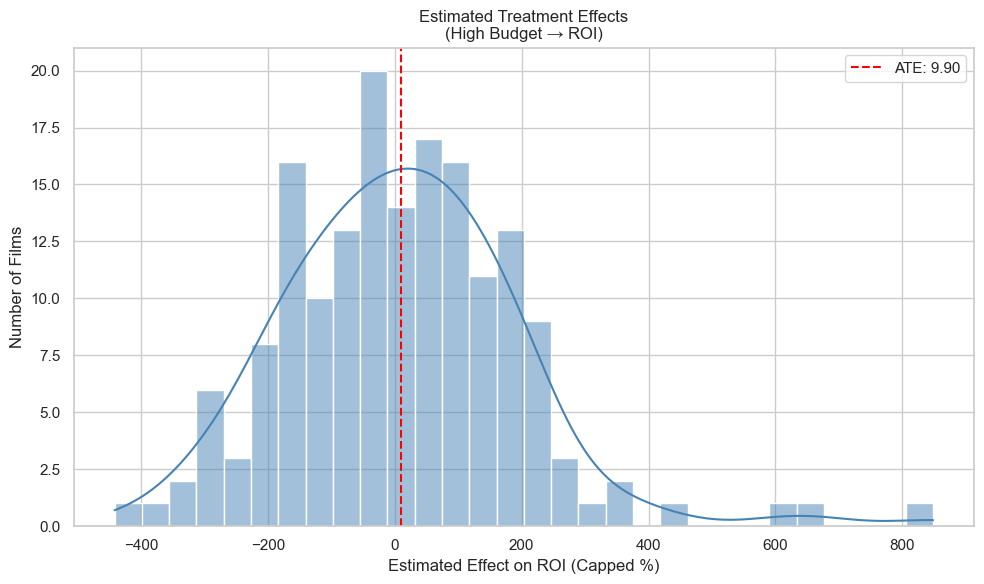

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

# Parse genre
df['Main_Genre'] = df['Genre'].apply(lambda x: eval(x)[0] if isinstance(x, str) else 'Unknown')

# Define high budget as treatment
df['High_Budget'] = (df['Budget'] >= 50000000).astype(int)

# Log budget
df['Log_Budget'] = np.log1p(df['Budget'])

# Drop missing final variables
df = df.dropna(subset=['ROI_Capped', 'High_Budget', 'IMDb_Rating', 'Running Time (minutes)', 'Log_Budget'])

# Set up model variables
Y = df['ROI_Capped'].reset_index(drop=True)
T = df['High_Budget'].reset_index(drop=True)

# Prepare features
X_raw = df[['Main_Genre', 'IMDb_Rating', 'Running Time (minutes)', 'Log_Budget']]
genre_encoder = OneHotEncoder(drop='first', sparse_output=False)
genre_encoded = genre_encoder.fit_transform(X_raw[['Main_Genre']])
genre_columns = genre_encoder.get_feature_names_out(['Main_Genre'])
X_other = X_raw.drop(columns=['Main_Genre']).reset_index(drop=True)
X_df = pd.concat([X_other, pd.DataFrame(genre_encoded, columns=genre_columns)], axis=1).reset_index(drop=True)

# Split data
X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(X_df, T, Y, test_size=0.2, random_state=42)

# Causal Forest
model = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=10, random_state=42),
    model_t=RandomForestClassifier(n_estimators=100, min_samples_leaf=10, random_state=42),
    discrete_treatment=True,
    random_state=42
)
model.fit(Y=Y_train, T=T_train, X=X_train)

# Estimate effects
treatment_effects = model.effect(X_test)
ate = np.mean(treatment_effects)
lower, upper = model.effect_interval(X_test)

# Output
print(f"95% Confidence Interval: [{lower.mean():.2f}, {upper.mean():.2f}]")
print(f"Estimated ATE (High Budget → ROI): {ate:.2f}")

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(treatment_effects, bins=30, kde=True, color='steelblue')
plt.axvline(ate, color='red', linestyle='--', label=f'ATE: {ate:.2f}')
plt.title('Estimated Treatment Effects\n(High Budget → ROI)')
plt.xlabel('Estimated Effect on ROI (Capped %)')
plt.ylabel('Number of Films')
plt.legend()
plt.tight_layout()
plt.show()